In [112]:
# Setup
from typing import List, Tuple
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Probability
### 1.1 Experimental Probability
- **Independent events:** Independent, if the probability of the second event isn't affected by the outcomes 
of the first event
- **Dependent events:** Dependent, if the probability of the second event is affected by the outcome of the first event.
- **Probability distribution:** Describes the probability of each possible outcome in a scenario.

Probability of an event:
$P(\text{event}) = \frac{\text{Number of favorable outcomes}}{\text{Total number of possible outcomes}}$

### 1.2 Sampling from uniform discrete distributions
- **Expected value (Discrete Case):** Mean of a probability distribution
$E[X] = \sum_{i=1}^{n} x_i \, P(x_i)$
- Basically a **weighted average** of all possible outcomes.

In [113]:
# Create a dice
die = pd.DataFrame({
    'number': range(1,7),
    'prob': np.round(np.repeat(1/6, 6),6)
})
# Sampling with replacement
print(die.sample(5, replace = True))
# Expected values as this is an uniform discrete distribution
print(f"Expected value: {np.mean(die['number'])}")


   number      prob
0       1  0.166667
1       2  0.166667
5       6  0.166667
1       2  0.166667
1       2  0.166667
Expected value: 3.5


### 1.3 Uniform Continuous Distributions

#### "Lower than" probabilities:
Percentage a bus (which can arrive in the next 12 minutes) will arrive in the next 7 minutes?

$P(\text{wait time} \leq 7)$

In [114]:
from scipy.stats import uniform
next_7_min = uniform.cdf(7,0,12)
next_11_min = uniform.cdf(11,0,12)
print(f"{round(next_7_min * 100,2)}%")
print(f"{round(next_11_min * 100,2)}%")

58.33%
91.67%


#### "Greater than" probabilities:
$P(\text{wait time} \geq 7) = 1 - P(\text{wait time} \leq 7)$

In [115]:
1 - uniform.cdf(7, 0 ,12)

np.float64(0.41666666666666663)

#### "In-Between" probabilities:

$P(4 \leq \text{wait time} \leq 7)$

In [116]:
uniform.cdf(7,0,12) - uniform.cdf(4,0,12)

np.float64(0.25000000000000006)

#### Generating random numbers according to uniform distribution

In [117]:
# Generate 10 uniformly distributed continuous variables between 2 and 9
uniform.rvs(loc = 2, scale = 7, size = 10) # scale = b-a = 7+2

array([4.56997798, 7.55906495, 5.70779213, 4.98193122, 2.64691683,
       2.18721241, 2.52301678, 8.31556299, 3.93060974, 3.00207157])

## 2 Law of large number
As the size of the sample increases, the sample mean will approach the expected value.

In [118]:
# 10 Rolls
rolls_10 = die.sample(10, replace = True)
rolls_100 = die.sample(100, replace = True)
rolls_1000 = die.sample(1000, replace = True)
rolls_10000000 = die.sample(10000000, replace = True)
# All mean
print(f"Population Mean: {np.mean(die['number'])}")
print(f"Sample Mean of 10 Values: {np.mean(rolls_10['number'])}")
print(f"Sample Mean of 100 Values: {np.mean(rolls_100['number'])}")
print(f"Sample Mean of 1000 Values: {np.mean(rolls_1000['number'])}")
print(f"Sample Mean of 10000000 Values: {np.mean(rolls_10000000['number'])}")

Population Mean: 3.5
Sample Mean of 10 Values: 3.2
Sample Mean of 100 Values: 3.37
Sample Mean of 1000 Values: 3.455
Sample Mean of 10000000 Values: 3.4994489


## 3 The binomial distribution
Probability distribution of the number of successes in a sequence of independent trials. Described by $n$ (total number of trials) and $p$ (probability of success).
- Success or Failure
- Win or Loss
- Yes or Non
- True or False

### 3.1 Single Binomial Distribution (Bernoulli trials)
- Expected value = n x p
#### 3.1.1 Generate binomial results
*binom.rvs(# of coins, probability of heads/success, size = # of trials)*

In [119]:
from scipy.stats import binom
binom.rvs(1, 0.5, size = 1)
# Many flips
binom.rvs(1, 0.5, size = 8)
# Many flips one time 
binom.rvs(8, 0.5, size = 1) # shows number of successes
# Other probabilities
binom.rvs(3, 0.25, size = 10)

array([2, 1, 1, 0, 1, 1, 2, 1, 0, 0])

#### 3.1.2 Probabily of distinct successes?
$P(\text{heads} = 7)$

*binom.pmf(# of heads, # of trials, probability of heads)*

In [120]:
binom.pmf(7, 10, 0.5)

np.float64(0.11718750000000004)

#### 3.1.3 Probability of 7 or fewer heads?
$P(\text{heads} \leq 7)$

*binom.cdf(# of successes, # of trials, probability of heads)*

In [121]:
binom.cdf(7, 10, 0.5)

np.float64(0.9453125)

#### 3.1.4 Probability of more than 7 heads?
$P(\text{heads} \geq 7)$

In [122]:
1 - binom.cdf(7, 10, 0.5)

np.float64(0.0546875)

## 4. The Normal Distribution

- Symmetrical
- Area under Curve = 1
- Curve never hits 0
- Described my mean and standard deviation
- 68% falls within 1 STD, 95% within 2 STD and 99.7% within 3 STD

### 4.1 norm.cdf(), norm.ppf() and norm.rvs()

### 4.1.1 What percent of women are short than 154cm?
*norm.cdf(x, mean, std)*

In [123]:
from scipy.stats import norm
result1 = norm.cdf(154, 161, 7)
print(f"{round(result1 * 100)}% of women are shorter than 154cm.")

16% of women are shorter than 154cm.


#### 4.1.2 What percent of women are taller than 154cm?
*1 - norm.cdf(x, mean, std)*

In [124]:
1 - norm.cdf(154, 161, 7)

np.float64(0.8413447460685429)

#### 4.1.3 What percent of women are 154-157cm?

In [125]:
norm.cdf(157, 161, 7) - norm.cdf(154, 161, 7)

np.float64(0.1251993291672192)

#### 4.1.4 What height are 90% of women shorter than? What taller?
*norm.ppf(perc, mean, std)*

In [126]:
print(round(norm.ppf(0.9, 161, 7),2))
print(round(norm.ppf((1-0.9), 161, 7),2))

169.97
152.03


#### 4.1.5 Generating random numbers?
*norm.rvs(mean, std, size)*

In [127]:
norm.rvs(161, 7, size = 10)

array([170.33643492, 167.72489431, 153.51233854, 163.05796072,
       150.68619739, 154.51989475, 152.80937051, 157.31460743,
       161.15460254, 160.1614997 ])

## 5. Central Limit Theorem

If we take many samples from any population (no matter what the original shape looks like - normal, skewed, uniform, etc.), and calculate the sample means, those means will form a normal distribution - as long as the sample size is large enough.

### 5.1 Sampling distrbution of means

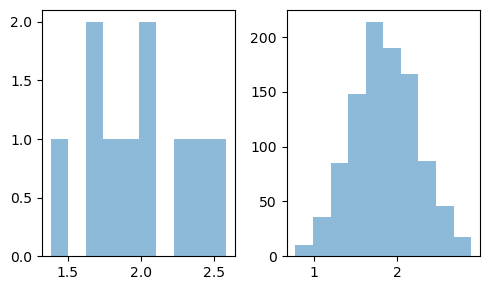

In [128]:
# 10 sample means
sample_means10 = []
for i in range(10):
    samp_5 = die.sample(5, replace= True)
    sample_means10.append(np.mean(samp_5))

# 1000 sample means
sample_means1000 = []
for i in range(1000):
    sample_means1000.append(np.mean(die.sample(5, replace=True)))

# Showing comparison
fig, ax = plt.subplots(1,2, figsize = (5,3))
ax[0].hist(sample_means10, alpha = 0.5)
ax[1].hist(sample_means1000, alpha = 0.5)
plt.tight_layout()
plt.show()

### 5.2 Sampling distribution of proportion

## 6. The Poisson distribution
- Events appear to have a certain rate, but completely at random
- E.g. Number of animals adopted from an animal shelter per week
- **Probability of some # of events occuring over a fixed period of time**
- **Lambda ($\lambda$)** = average number of events per time interval (Avg. # of adoptions per week)
- Lambda is the distribution's peak
- Expected value: $\lambda$

### 6.1 Probability of a single value
$P(\text{Number of adoptions in a week} = 5)$

In [129]:
from scipy.stats import poisson
# If the average number of adoptions per week is 8, what is P(# = 5)?
poisson.pmf(5,8)

np.float64(0.09160366159257921)

$P(\text{Number of adoptions in a week} \leq 5)$

In [130]:
poisson.cdf(5,8)

np.float64(0.1912360620796254)

$P(\text{Number of adoptions} \geq 5)$

In [131]:
1 - poisson.cdf(5,8)

np.float64(0.8087639379203746)

### 6.2 Sampling from a Poisson distribution

In [132]:
poisson.rvs(8, size = 10)

array([11,  5,  7,  9,  6,  8, 10, 13,  9,  8])

## 7. Exponential distribution

- Probability of time between Poisson events
- E.g. Probability of < 10 minutes between restaurant arrivals
- Continuous (time) and also uses lambda (rate)
- Expected value: 1/ $\lambda$

In [133]:
# If lambda = 0.5 (given)
from scipy.stats import expon
# P(wait > 4min)
p_wait_gr_4_min = 1 - expon.cdf(4, scale = 2) # scale = 1/lambda = 2
p_wait_le_1_min = expon.cdf(1, scale = 2)
p_1_min_wait_4_min = expon.cdf(4, scale = 2) - expon.cdf(1, scale = 2)
print(f"P(wait > 4min): {p_wait_gr_4_min}")
print(f"P(wait < 1min): {p_wait_le_1_min}")
print(f"P(1min < wait < 4min): {p_1_min_wait_4_min}")


P(wait > 4min): 0.1353352832366127
P(wait < 1min): 0.3934693402873666
P(1min < wait < 4min): 0.4711953764760207


## 8. (Student's) t-distribution
- Has a parameter **degrees of freedom (df)** which affects the thickness of the tails
- Lower df = thicker tails, higher std
- Higher df = closer to normal distribution